# 3. An ARX model for the heating of a box

The final part is about identifying a suitable ARX model for predicting the hourly heating of a test
box (a small building). The box has a window in the south facing wall.

In an experiment times series were recorded of the variables:
- $P_h$ (*Ph* in data) the heat from electrical heaters (W).
- $T_{delta}$ (*Tdelta* in data) the difference between the internal and external temperature (◦C)
- $G_v$ (*Gv* in data) the vertical solar radiation onto the box side with a window (W/m2)

The data consists of average hourly values – in total 231 hours. It’s available in the *box_data_60min.csv*
file.

In the experiment the internal air temperature was kept constant with a thermostatic control of the
heating – hence the heating change depending on the weather conditions.

The objective is to find a suitable model, which makes good predictions of the heating.

Lags have been generated and included in the data with a naming syntax such that, e.g.: *Ph.l1* is the
heating lagged one step, *Ph.l2* is heating lagged two steps and so fourth.

In [67]:
import pandas as pd
import matplotlib.pyplot as plt

### 3.1. Read the data and plot the three non-lagged time series (*Ph*, *Tdelta*, *Gv*). Describe the time series and if you can see some dependencies between the variables.

#### Load the data

In [68]:
from pathlib import Path
print(Path.cwd())

c:\Users\manon\OneDrive\Bureau\Danemark\DTU\Spring 2026\02417 Time Series Analysis\02417---Time-Series-Analysis\assignments\Assignment3


In [69]:
df = pd.read_csv(r'C:\Users\manon\OneDrive\Bureau\Danemark\DTU\Spring 2026\02417 Time Series Analysis\02417---Time-Series-Analysis\assignments\Assignment3\assignment3_2026\box_data_60min.csv')

In [70]:
print(df.columns)
print(df.head)

Index(['thour', 'tdate', 'Ph', 'Tdelta', 'Gv', 'Ph.l0', 'Ph.l1', 'Ph.l2',
       'Ph.l3', 'Ph.l4', 'Ph.l5', 'Ph.l6', 'Ph.l7', 'Ph.l8', 'Ph.l9', 'Ph.l10',
       'Tdelta.l0', 'Tdelta.l1', 'Tdelta.l2', 'Tdelta.l3', 'Tdelta.l4',
       'Tdelta.l5', 'Tdelta.l6', 'Tdelta.l7', 'Tdelta.l8', 'Tdelta.l9',
       'Tdelta.l10', 'Gv.l0', 'Gv.l1', 'Gv.l2', 'Gv.l3', 'Gv.l4', 'Gv.l5',
       'Gv.l6', 'Gv.l7', 'Gv.l8', 'Gv.l9', 'Gv.l10'],
      dtype='object')
<bound method NDFrame.head of      thour                tdate  Ph     Tdelta          Gv  Ph.l0  Ph.l1  \
0       19  2013-01-30 02:00:00  56  13.253583   -0.498643     56     55   
1       20  2013-01-30 03:00:00  54  13.181458   -1.127035     54     56   
2       21  2013-01-30 04:00:00  55  12.968792   -0.643298     55     54   
3       22  2013-01-30 05:00:00  54  12.667750   -0.456008     54     55   
4       23  2013-01-30 06:00:00  54  12.605250   -1.534060     54     54   
..     ...                  ...  ..        ...         ...    ...

#### Create the plot

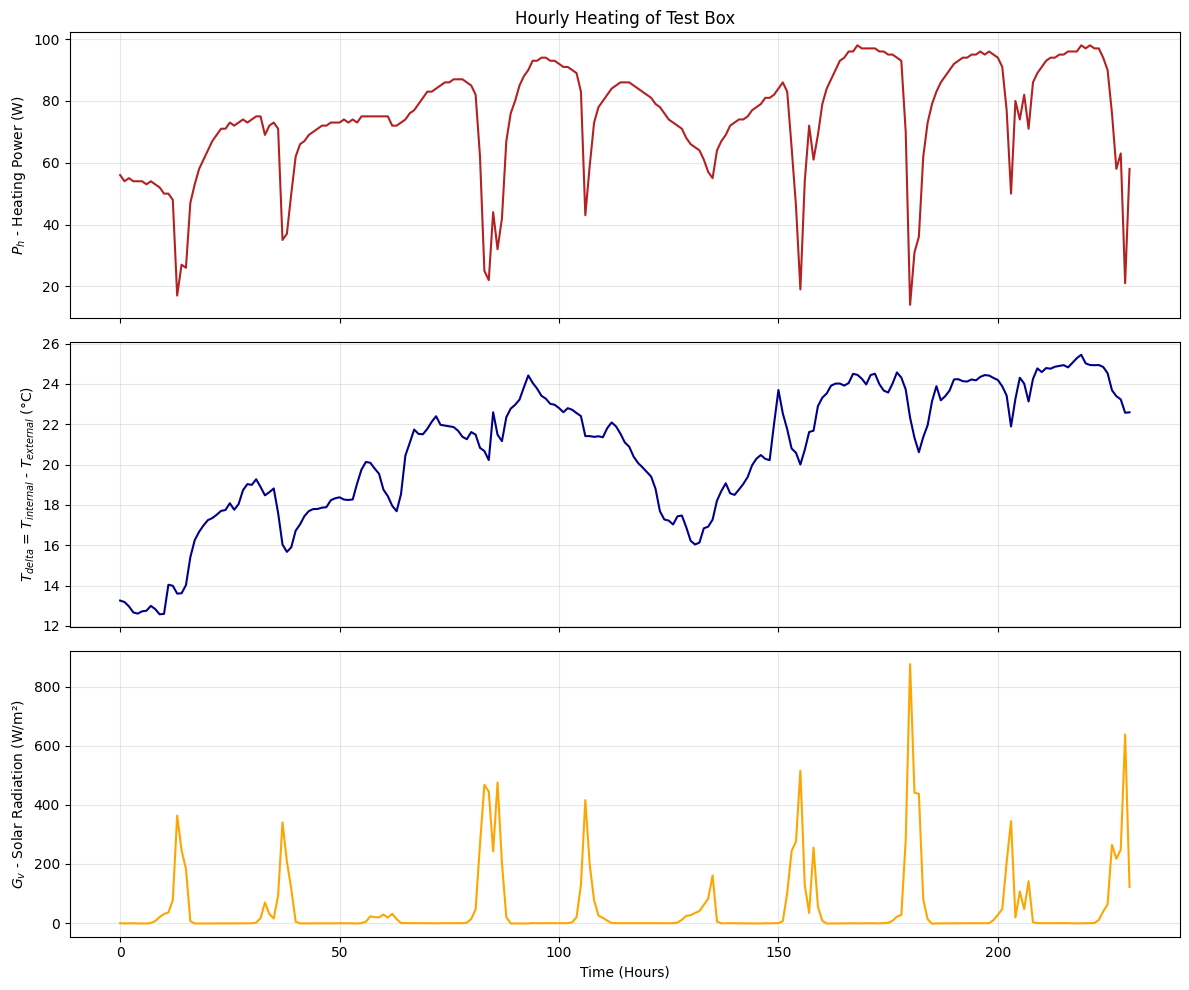

In [71]:
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

# Plot Heating Power (Ph)
axes[0].plot(df['Ph'], color='firebrick', linewidth=1.5)
axes[0].set_ylabel('$P_h$ - Heating Power (W)')
axes[0].set_title('Hourly Heating of Test Box')
axes[0].grid(True, alpha=0.3)

# Plot Temperature Difference (Tdelta)
axes[1].plot(df['Tdelta'], color='darkblue', linewidth=1.5)
axes[1].set_ylabel('$T_{delta}$ = $T_{internal}$ - $T_{external}$ (°C)')
axes[1].grid(True, alpha=0.3)

# Plot Solar Radiation (Gv)
axes[2].plot(df['Gv'], color='orange', linewidth=1.5)
axes[2].set_ylabel('$G_v$ - Solar Radiation (W/m²)')
axes[2].set_xlabel('Time (Hours)')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 3.2. Split the data into a train and test set, such that ”2013-02-06 00:00” is the last data point in the training set (i.e. $t_{hour}$ = 1, ..., 167 is the training set). From now on, work only on the training set, except where explicitly told to use the test set.

#### Split the data

In [72]:
# Define the split point
train_size = 167

# Split the data
train_df = df.iloc[:train_size].copy()
test_df = df.iloc[train_size:].copy()

#### Verification

In [73]:
# Verify the split
print(f"Training set: {train_df.shape[0]} samples")
print(f"Test set:     {test_df.shape[0]} samples")

# Display the last timestamp of the training set to ensure it matches "2013-02-06 00:00"
final_timestamp = train_df['tdate'].iloc[-1]
print(f"Last training timestamp: {final_timestamp}")

Training set: 167 samples
Test set:     64 samples
Last training timestamp: 2013-02-06 00:00:00


### 3.3. Investigate the variables and their relations: e.g. with scatter, auto-correlation and cross-correlation plots. Most focus on $P_h$. Highlight key aspects of the dynamics and interrelationships among the variables. What can be seen directly and what cannot?

In [74]:
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

#### Scatter Plots with Regression Lines

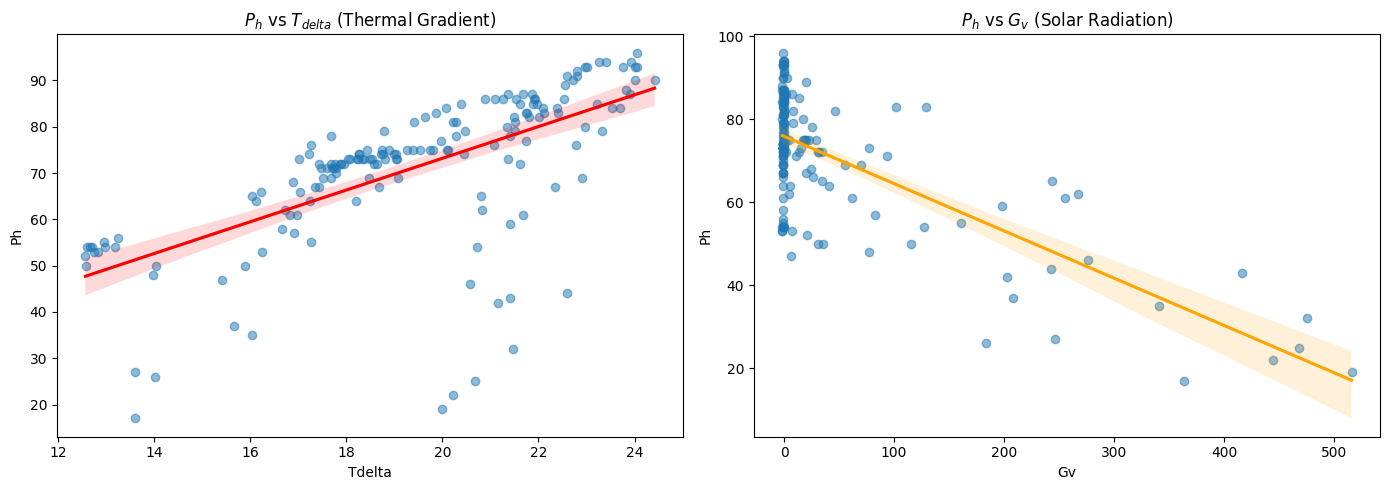

In [75]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

sns.regplot(data=train_df, x='Tdelta', y='Ph', ax=ax[0], scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
ax[0].set_title('$P_h$ vs $T_{delta}$ (Thermal Gradient)')

sns.regplot(data=train_df, x='Gv', y='Ph', ax=ax[1], scatter_kws={'alpha':0.5}, line_kws={'color':'orange'})
ax[1].set_title('$P_h$ vs $G_v$ (Solar Radiation)')
plt.tight_layout()
plt.show()

#### Auto-correlation (ACF) and Partial Auto-correlation (PACF) for $P_h$

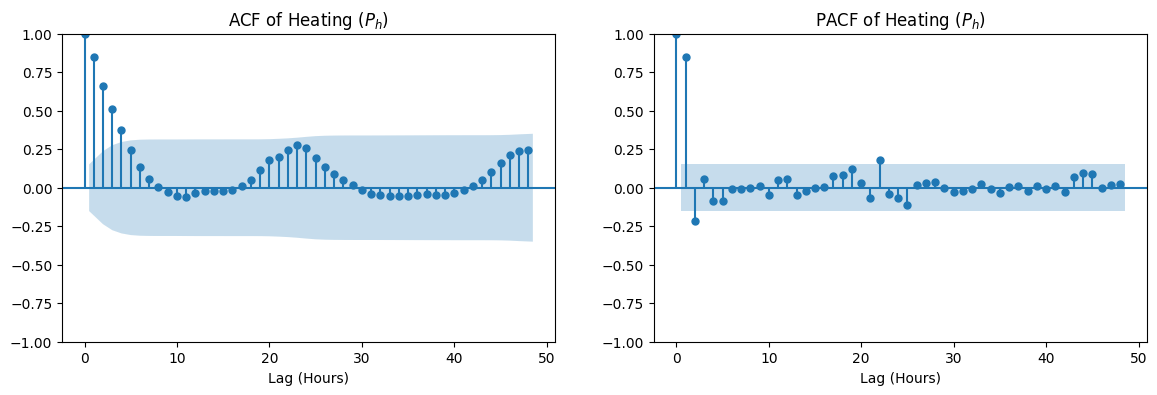

In [76]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(train_df['Ph'], lags=48, ax=ax[0], title='ACF of Heating ($P_h$)')
plot_pacf(train_df['Ph'], lags=48, ax=ax[1], title='PACF of Heating ($P_h$)')
ax[0].set_xlabel('Lag (Hours)')
ax[1].set_xlabel('Lag (Hours)')
plt.show()

#### Cross-correlation (CCF)

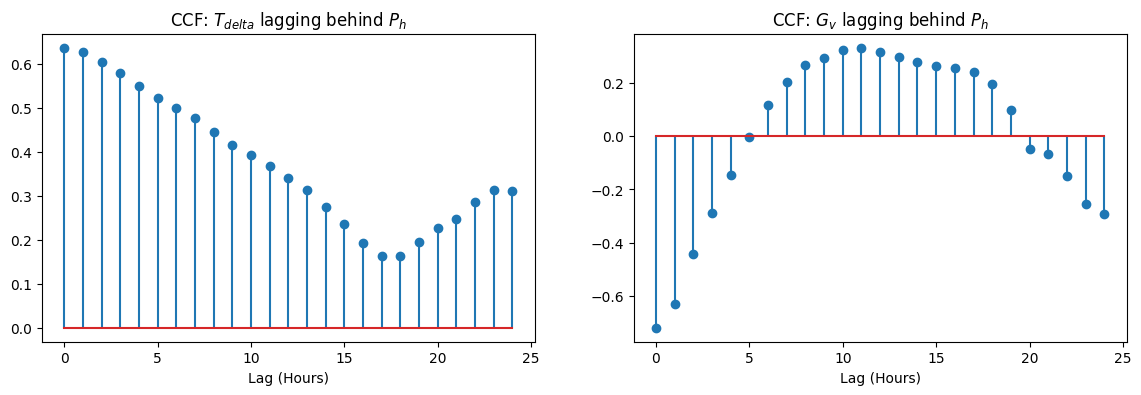

In [77]:
# ccf(x, y) shows how x at time t correlates with y at time t+k
fig, ax = plt.subplots(1, 2, figsize=(14, 4))

# CCF: Tdelta and Ph
ccf_tdelta = [train_df['Ph'].corr(train_df['Tdelta'].shift(i)) for i in range(25)]
ax[0].stem(range(25), ccf_tdelta)
ax[0].set_title('CCF: $T_{delta}$ lagging behind $P_h$')
ax[0].set_xlabel('Lag (Hours)')

# CCF: Gv and Ph
ccf_gv = [train_df['Ph'].corr(train_df['Gv'].shift(i)) for i in range(25)]
ax[1].stem(range(25), ccf_gv)
ax[1].set_title('CCF: $G_v$ lagging behind $P_h$')
ax[1].set_xlabel('Lag (Hours)')
plt.show()

### 3.4. Estimate the impulse response from $T_{delta}$ and $G_v$ to $P_h$ make it up to lag 10. Present it for both variables in plots and comment.

In [78]:
import statsmodels.api as sm

In [79]:
def estimate_irf(target, exogenous, max_lag=10):
    # Create a DataFrame for the lagged exogenous variables
    lag_cols = pd.DataFrame(index=target.index)
    for i in range(max_lag + 1):
        lag_cols[f'lag_{i}'] = exogenous.shift(i)
    
    # Drop rows with NaN from shifting
    valid_data = pd.concat([target, lag_cols], axis=1).dropna()
    
    y = valid_data[target.name]
    X = valid_data.drop(columns=[target.name])
    X = sm.add_constant(X) # Include intercept
    
    model = sm.OLS(y, X).fit()
    # Return coefficients for lag_0 to lag_10 (skipping the constant)
    return model.params[1:], model.bse[1:]

# Calculate IRFs (Impulse Response Functions) using the training data
irf_tdelta, stderr_tdelta = estimate_irf(train_df['Ph'], train_df['Tdelta'], max_lag=10)
irf_gv, stderr_gv = estimate_irf(train_df['Ph'], train_df['Gv'], max_lag=10)

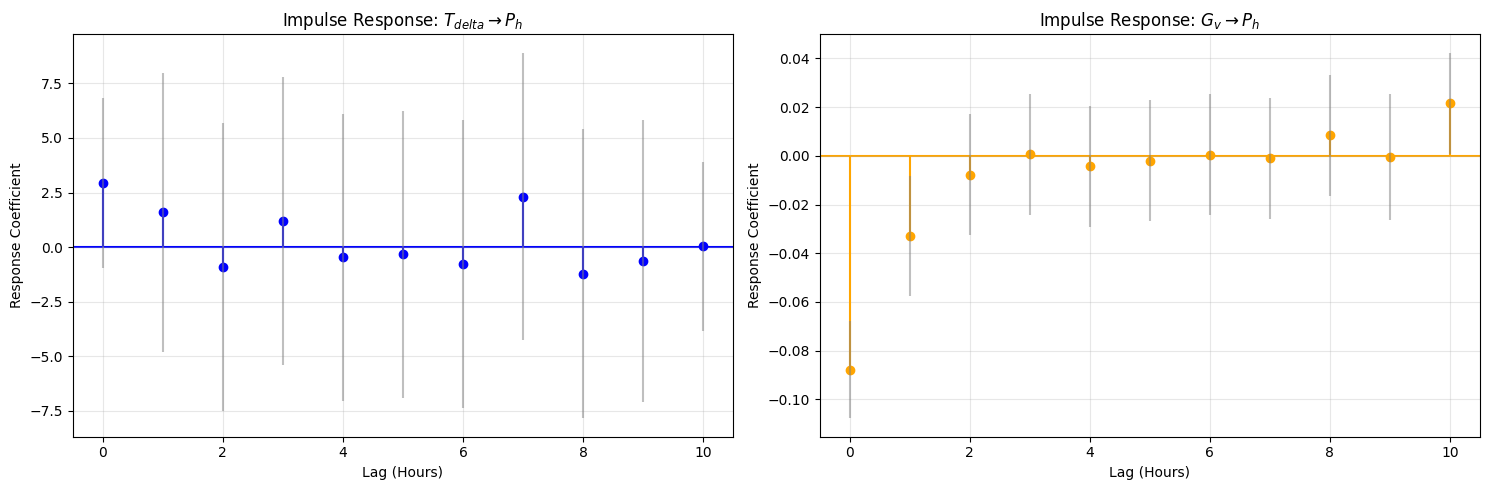

In [80]:
# Plotting
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot for Tdelta
axes[0].stem(range(11), irf_tdelta, basefmt=" ", linefmt='blue')
axes[0].errorbar(range(11), irf_tdelta, yerr=1.96*stderr_tdelta, fmt='none', ecolor='gray', alpha=0.5)
axes[0].axhline(0, color='blue', linewidth=1.5, zorder=1)
axes[0].set_title('Impulse Response: $T_{delta} \\rightarrow P_h$')
axes[0].set_xlabel('Lag (Hours)')
axes[0].set_ylabel('Response Coefficient')
axes[0].grid(True, alpha=0.3)

# Plot for Gv
axes[1].stem(range(11), irf_gv, basefmt=" ", linefmt='orange')
axes[1].errorbar(range(11), irf_gv, yerr=1.96*stderr_gv, fmt='none', ecolor='gray', alpha=0.5)
axes[1].axhline(0, color='orange', linewidth=1.5, zorder=1)
axes[1].set_title('Impulse Response: $G_v \\rightarrow P_h$')
axes[1].set_xlabel('Lag (Hours)')
axes[1].set_ylabel('Response Coefficient')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 3.5. Fit the linear regression model $P_{h,t} = ω_1 T_{delta,t} + ω_2 G_{v,t} + ε_t$. The error is assumed $ε_t ∼ N (0, σ^2)$ and i.i.d. Analyse the estimation result, one-step prediction, residuals with plots, ACF and CCF. Comment with focus on the potential need for a model which includes a transfer function.

#### Fit the Linear Regression Model (Static)

In [81]:
X = train_df[['Tdelta', 'Gv']]
X = sm.add_constant(X)
y = train_df['Ph']

model_static = sm.OLS(y, X).fit()
train_df['pred_static'] = model_static.predict(X)
train_df['residuals'] = model_static.resid

In [82]:
print(model_static.summary())

                            OLS Regression Results                            
Dep. Variable:                     Ph   R-squared:                       0.898
Model:                            OLS   Adj. R-squared:                  0.897
Method:                 Least Squares   F-statistic:                     722.6
Date:                Thu, 26 Mar 2026   Prob (F-statistic):           4.73e-82
Time:                        11:45:06   Log-Likelihood:                -510.21
No. Observations:                 167   AIC:                             1026.
Df Residuals:                     164   BIC:                             1036.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         11.1484      2.642      4.220      0.0

#### Visualization: Predictions and Residuals

<>:12: SyntaxWarning: invalid escape sequence '\e'
<>:12: SyntaxWarning: invalid escape sequence '\e'
C:\Users\manon\AppData\Local\Temp\ipykernel_44088\444078355.py:12: SyntaxWarning: invalid escape sequence '\e'
  axes[0,1].set_title('Residuals $\epsilon_t$ over Time')


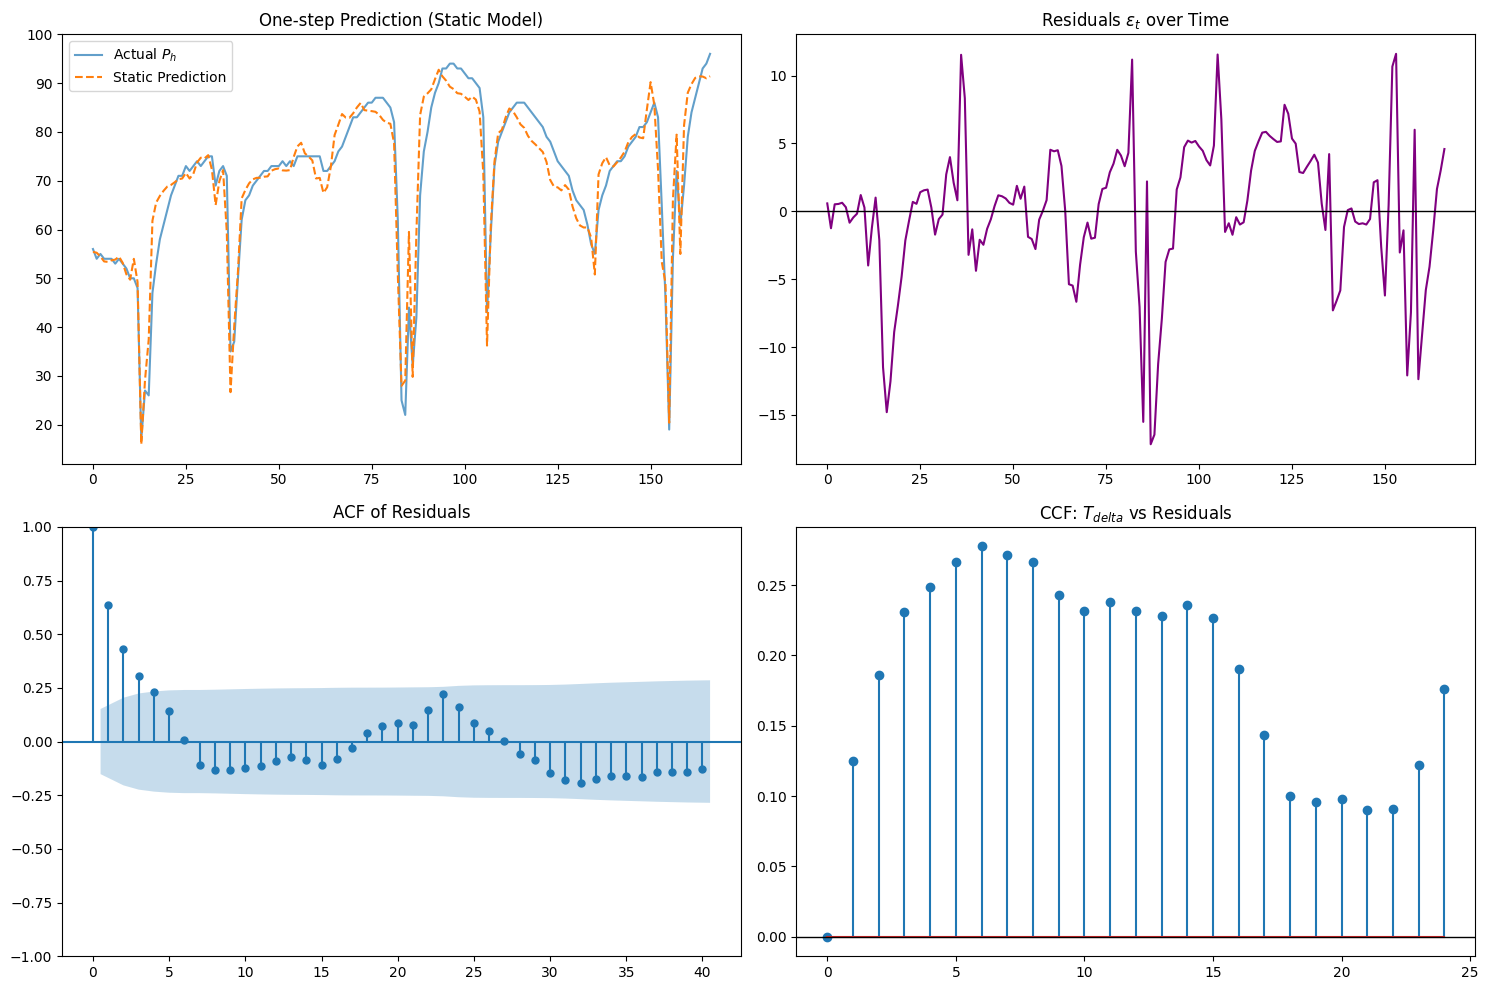

In [83]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Time Series Plot: Actual vs Predicted
axes[0,0].plot(train_df.index, train_df['Ph'], label='Actual $P_h$', alpha=0.7)
axes[0,0].plot(train_df.index, train_df['pred_static'], label='Static Prediction', linestyle='--')
axes[0,0].set_title('One-step Prediction (Static Model)')
axes[0,0].legend()

# Residuals over time
axes[0,1].plot(train_df.index, train_df['residuals'], color='purple')
axes[0,1].axhline(0, color='black', lw=1)
axes[0,1].set_title('Residuals $\epsilon_t$ over Time')

# ACF of Residuals (Check for independence)
plot_acf(train_df['residuals'], lags=40, ax=axes[1,0], title='ACF of Residuals')

# CCF between Tdelta and Residuals (Check for unmodeled dynamics)
# Manual CCF calculation for residuals
res_ccf = [train_df['residuals'].corr(train_df['Tdelta'].shift(i)) for i in range(25)]
axes[1,1].stem(range(25), res_ccf)
axes[1,1].axhline(0, color='black', lw=1)
axes[1,1].set_title('CCF: $T_{delta}$ vs Residuals')

plt.tight_layout()
plt.show()

### 3.6. Fit the first order ARX model $P_{h,t} = -\Phi_1 P_{h,t-1} + ω_1 T_{delta,t} + ω_2 G_{v,t} + ε_t$. Note the sign of $\Phi$ in the equation, as you know, it’s just to keep the same notation throughout, in practice just estimate the coefficients and only if you need to consider their value remember potential sign flip. Analyse the one-step predictions and residuals as above. Comment, was an improvement achieved?

In [2]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from pathlib import Path

# Reuse existing train_df if available; otherwise load and split data
if 'train_df' not in globals():
    candidate_paths = [
        Path('assignments/Assignment3/assignment3_2026/box_data_60min.csv'),
        Path('assignment/Assignment3/assignment3_2026/box_data_60min.csv'),
        Path(r'C:\Users\leahi\Documents\DTU\Time Series Analysis\assignments\Assignment3\assignment3_2026\box_data_60min.csv')
    ]
    data_path = next((p for p in candidate_paths if p.exists()), None)
    if data_path is None:
        raise FileNotFoundError('box_data_60min.csv not found in expected locations.')
    df = pd.read_csv(data_path)
    train_df = df.iloc[:167].copy()

# Static model: same as 3.5, but don't need to re-run if already available
if 'model_static' in globals() and 'pred_static' in train_df.columns and 'residuals' in train_df.columns:
    model_static_q35 = model_static
    train_df['pred_static_q35'] = train_df['pred_static']
    train_df['resid_static_q35'] = train_df['residuals']
    static_source = 'Reused exact 3.5 objects (model_static, pred_static, residuals)'
else:
    X = train_df[['Tdelta', 'Gv']]
    X = sm.add_constant(X)
    y = train_df['Ph']

    model_static_q35 = sm.OLS(y, X).fit()
    train_df['pred_static_q35'] = model_static_q35.predict(X)
    train_df['resid_static_q35'] = model_static_q35.resid
    static_source = 'Recomputed using exact 3.5 code block'

# ARX(1) design matrix: Ph_t ~ Ph_{t-1} + Tdelta_t + Gv_t
train_arx = train_df.copy()
if 'Ph.l1' in train_arx.columns:
    train_arx['Ph_l1'] = train_arx['Ph.l1']
else:
    train_arx['Ph_l1'] = train_arx['Ph'].shift(1)

arx_data = train_arx[['Ph', 'Ph_l1', 'Tdelta', 'Gv']].dropna().copy()
y_arx = arx_data['Ph']
X_arx = sm.add_constant(arx_data[['Ph_l1', 'Tdelta', 'Gv']])

model_arx1 = sm.OLS(y_arx, X_arx).fit()
arx_data['pred_arx1'] = model_arx1.predict(X_arx)
arx_data['resid_arx1'] = y_arx - arx_data['pred_arx1']

# Meaningful comparison: evaluate both models on the ARX-available timestamps
common_idx = arx_data.index
arx_data['pred_static_q35'] = train_df.loc[common_idx, 'pred_static_q35']
arx_data['resid_static_q35'] = arx_data['Ph'] - arx_data['pred_static_q35']

rmse_static_common = np.sqrt(np.mean(arx_data['resid_static_q35']**2))
rmse_arx1 = np.sqrt(np.mean(arx_data['resid_arx1']**2))
improvement_pct = 100 * (rmse_static_common - rmse_arx1) / rmse_static_common

# In assignment notation: Ph,t = -phi1*Ph,t-1 + ... => phi1 = -coef(Ph_l1)
phi1_notation = -model_arx1.params['Ph_l1']

print('=== ARX(1) coefficients (estimated directly) ===')
print(model_arx1.params)
print('\n=== Converted to assignment notation ===')
print(f'phi1 (assignment sign convention) = {phi1_notation:.4f}')
print(f'omega1 (Tdelta) = {model_arx1.params["Tdelta"]:.4f}')
print(f'omega2 (Gv)     = {model_arx1.params["Gv"]:.4f}')
print('\n=== 3.5-style comparison ===')
print(static_source)
print('RMSE comparison is computed on the common ARX-available timestamps.')
print(f'RMSE static (common sample) : {rmse_static_common:.4f}')
print(f'RMSE ARX(1)                 : {rmse_arx1:.4f}')
print(f'RMSE improvement            : {improvement_pct:.2f}%')
print(f'AIC static (3.5 fit)        : {model_static_q35.aic:.2f}')
print(f'AIC ARX(1)                  : {model_arx1.aic:.2f}')

arx_results = {
    'model_arx1': model_arx1,
    'model_static_q35': model_static_q35,
    'data': arx_data,
    'rmse_static_common': rmse_static_common,
    'rmse_arx1': rmse_arx1,
    'improvement_pct': improvement_pct,
    'phi1_notation': phi1_notation,
    'static_source': static_source,
}

=== ARX(1) coefficients (estimated directly) ===
const     5.365384
Ph_l1     0.404646
Tdelta    2.095989
Gv       -0.085146
dtype: float64

=== Converted to assignment notation ===
phi1 (assignment sign convention) = -0.4046
omega1 (Tdelta) = 2.0960
omega2 (Gv)     = -0.0851

=== 3.5-style comparison ===
Recomputed using exact 3.5 code block
RMSE comparison is computed on the common ARX-available timestamps.
RMSE static (common sample) : 5.1356
RMSE ARX(1)                 : 2.5504
RMSE improvement            : 50.34%
AIC static (3.5 fit)        : 1026.42
AIC ARX(1)                  : 794.63


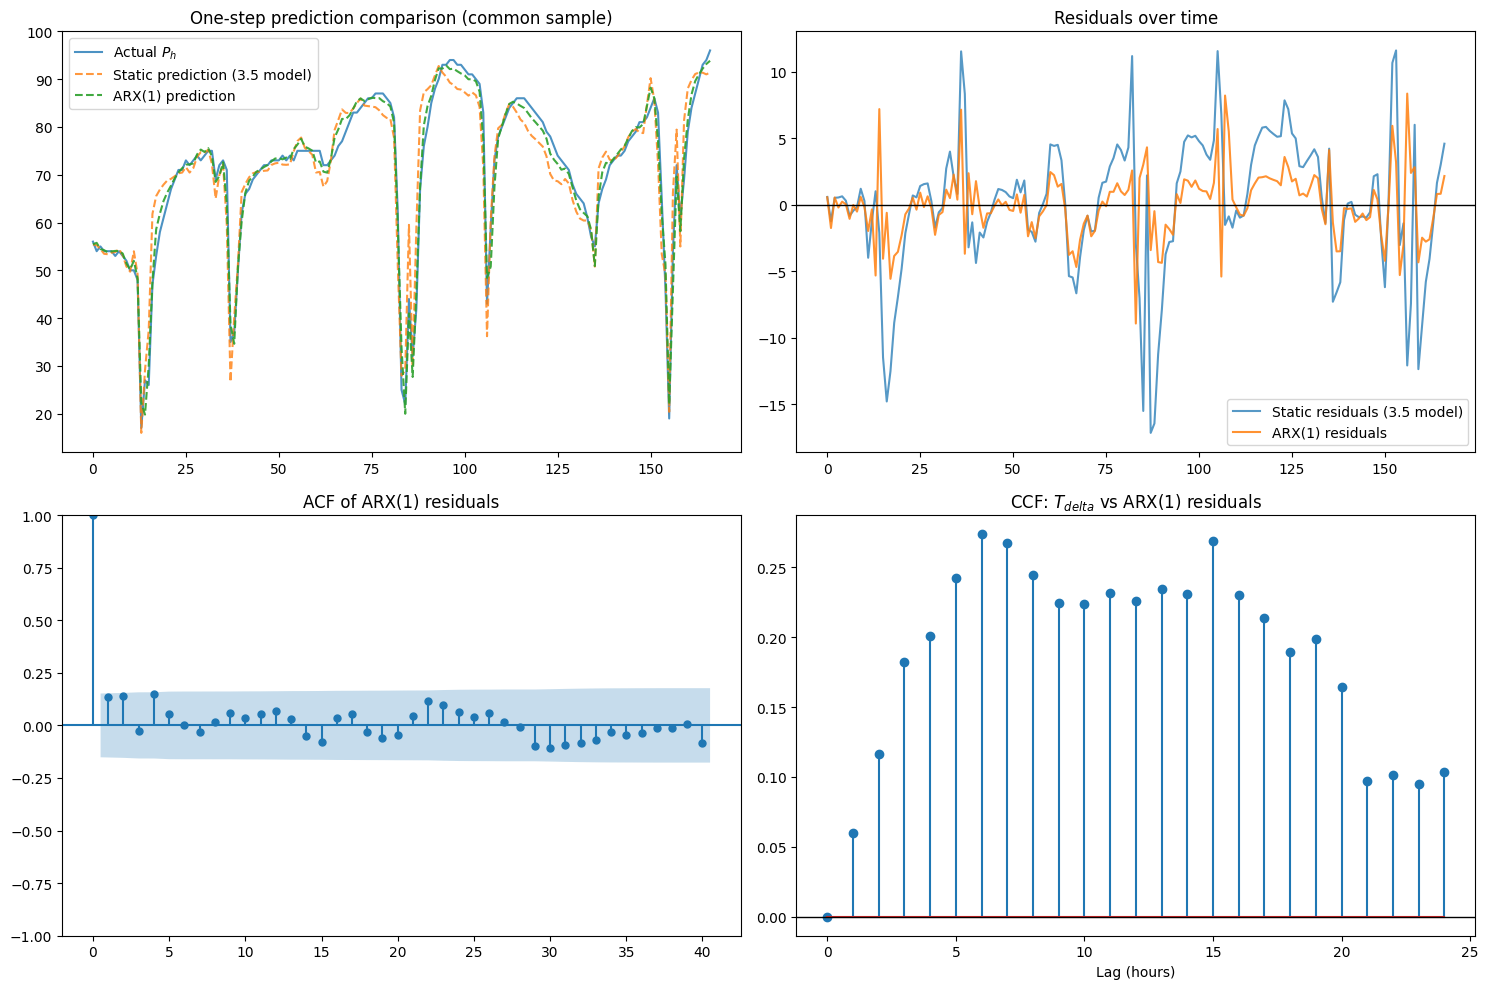

In [10]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf

arx_data = arx_results['data']

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1) Actual vs predictions
axes[0, 0].plot(arx_data.index, arx_data['Ph'], label='Actual $P_h$', alpha=0.8)
axes[0, 0].plot(arx_data.index, arx_data['pred_static_q35'], '--', label='Static prediction (3.5 model)', alpha=0.8)
axes[0, 0].plot(arx_data.index, arx_data['pred_arx1'], '--', label='ARX(1) prediction', alpha=0.9)
axes[0, 0].set_title('One-step prediction comparison (common sample)')
axes[0, 0].legend()

# 2) Residuals over time
axes[0, 1].plot(arx_data.index, arx_data['resid_static_q35'], label='Static residuals (3.5 model)', alpha=0.75)
axes[0, 1].plot(arx_data.index, arx_data['resid_arx1'], label='ARX(1) residuals', alpha=0.85)
axes[0, 1].axhline(0, color='black', lw=1)
axes[0, 1].set_title('Residuals over time')
axes[0, 1].legend()

# 3) ACF of ARX residuals
plot_acf(arx_data['resid_arx1'], lags=40, ax=axes[1, 0], title='ACF of ARX(1) residuals')

# 4) CCF: Tdelta vs ARX residuals
ccf_tdelta_arx = [arx_data['resid_arx1'].corr(arx_data['Tdelta'].shift(i)) for i in range(25)]
axes[1, 1].stem(range(25), ccf_tdelta_arx)
axes[1, 1].axhline(0, color='black', lw=1)
axes[1, 1].set_title('CCF: $T_{delta}$ vs ARX(1) residuals')
axes[1, 1].set_xlabel('Lag (hours)')

plt.tight_layout()
plt.show()

### Comment on improvements, to be finished!!!!

“Compared with the static regression, the ARX(1) model reduces RMSE by **X%** and has a lower AIC (**AIC_ARX < AIC_static**). The residual ACF/CCF also show less remaining structure, so the first-order ARX specification provides a clear improvement in one-step prediction performance.”



### 3.7. Increase the model order of the ARX. The second order model is Ph,t = −φ1Ph,t−1 −φ2Ph,t−2 + ω1,0Tdelta,t + ω1,1Tdelta,t−1 + ω2,0Gv,t + ω2,1Gv,t−1 + εt hence keep the same number of lags for all inputs. Plot BIC and AIC vs. the increasing model order. Explain the difference between the two curves, and consider what model order you would select based on this?

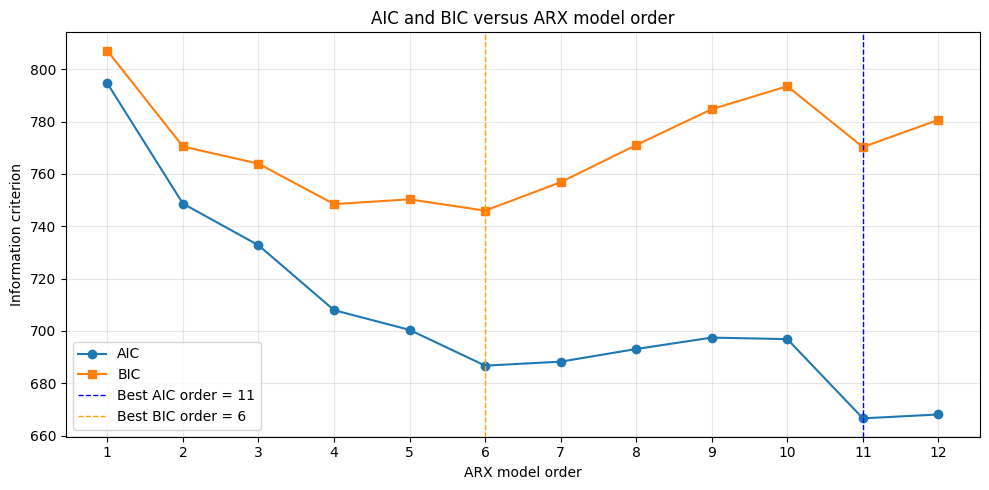

 order        AIC        BIC  nobs  k_params
     1 794.627356 807.099332   167         4
     2 748.670841 770.496798   167         7
     3 732.749121 763.929059   167        10
     4 707.944273 748.478193   167        13
     5 700.406608 750.294509   167        16
     6 686.727212 745.969094   167        19
     7 688.250400 756.846264   167        22
     8 693.090167 771.040012   167        25
     9 697.449471 784.753297   167        28
    10 696.865100 793.522908   167        31
    11 666.588041 770.283145   156        34
    12 668.071122 780.677852   155        37

Best order by AIC: 11
Best order by BIC: 6


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

# Use training data already created above (fallback only if missing)
if 'train_df' not in globals():
    train_df = df.iloc[:167].copy()

def fit_arx_order(data, order):
    """Fit ARX(order) with same number of lags for output and each input.
    Model: Ph_t depends on Ph_{t-1..t-order}, Tdelta_{t..t-order+1}, Gv_{t..t-order+1}."""
    work = data.copy()

    # Output lags: 1..order
    for lag in range(1, order + 1):
        src = f'Ph.l{lag}'
        col = f'Ph_l{lag}'
        if src in work.columns:
            work[col] = work[src]
        else:
            work[col] = work['Ph'].shift(lag)

    # Input lags: 0..order-1
    for lag in range(0, order):
        src_td = f'Tdelta.l{lag}'
        src_gv = f'Gv.l{lag}'
        col_td = f'Tdelta_l{lag}'
        col_gv = f'Gv_l{lag}'
        if lag == 0:
            work[col_td] = work['Tdelta']
            work[col_gv] = work['Gv']
        else:
            work[col_td] = work[src_td] if src_td in work.columns else work['Tdelta'].shift(lag)
            work[col_gv] = work[src_gv] if src_gv in work.columns else work['Gv'].shift(lag)

    feature_cols = [f'Ph_l{lag}' for lag in range(1, order + 1)] + [
        f'Tdelta_l{lag}' for lag in range(0, order)
    ] + [
        f'Gv_l{lag}' for lag in range(0, order)
    ]

    model_data = work[['Ph'] + feature_cols].dropna().copy()
    y = model_data['Ph']
    X = sm.add_constant(model_data[feature_cols])
    model = sm.OLS(y, X).fit()
    return model, model_data

max_order = 12
records = []
models_by_order = {}

for p in range(1, max_order + 1):
    model_p, data_p = fit_arx_order(train_df, p)
    records.append({
        'order': p,
        'AIC': model_p.aic,
        'BIC': model_p.bic,
        'nobs': int(model_p.nobs),
        'k_params': int(model_p.df_model + 1)
    })
    models_by_order[p] = model_p

criteria_df = pd.DataFrame(records)
best_aic_order = int(criteria_df.loc[criteria_df['AIC'].idxmin(), 'order'])
best_bic_order = int(criteria_df.loc[criteria_df['BIC'].idxmin(), 'order'])

plt.figure(figsize=(10, 5))
plt.plot(criteria_df['order'], criteria_df['AIC'], marker='o', label='AIC')
plt.plot(criteria_df['order'], criteria_df['BIC'], marker='s', label='BIC')
plt.axvline(best_aic_order, linestyle='--', linewidth=1, color='blue', label=f'Best AIC order = {best_aic_order}')
plt.axvline(best_bic_order, linestyle='--', linewidth=1, color='orange', label=f'Best BIC order = {best_bic_order}')
plt.xlabel('ARX model order')
plt.ylabel('Information criterion')
plt.title('AIC and BIC versus ARX model order')
plt.xticks(criteria_df['order'])
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print(criteria_df.to_string(index=False))
print(f'\nBest order by AIC: {best_aic_order}')
print(f'Best order by BIC: {best_bic_order}')

arx_order_results = {
    'criteria': criteria_df,
    'models_by_order': models_by_order,
    'best_aic_order': best_aic_order,
    'best_bic_order': best_bic_order
}

### Comment on AIC/BIC curves (fill with your values)

Use the output from the previous cell:

- AIC-optimal order: **p = ...**
- BIC-optimal order: **p = ...**

Interpretation guide:

- AIC and BIC both balance fit and complexity, but BIC penalizes complexity more strongly.
- Therefore, BIC typically selects a smaller order than AIC (or the same in simple cases).
- If the AIC curve keeps decreasing while BIC reaches a minimum earlier, it indicates marginal fit gains from extra parameters but stronger overfitting risk.
- A practical choice is often the BIC order for parsimony, unless prediction-focused validation clearly favors the larger AIC order.

Suggested conclusion sentence:
“The AIC/BIC curves suggest an optimal ARX order between the BIC minimum (more parsimonious) and the AIC minimum (more flexible). I select order **p = ...** because it provides a good trade-off between fit and complexity.”

### 3.8. One-step predictions on test period and RMSE vs model order

Compute one-step predictions on the test period ($t=168,\dots,231$), i.e. 64 points.
For each ARX order, evaluate:

$$
\mathrm{RMSE}=\sqrt{\frac{1}{64}\sum_{t=168}^{231} e_t^2}, \quad e_t = P_{h,t}-\hat P_{h,t|t-1}
$$

Then compare the RMSE-optimal order with the AIC/BIC-optimal orders from 3.7.

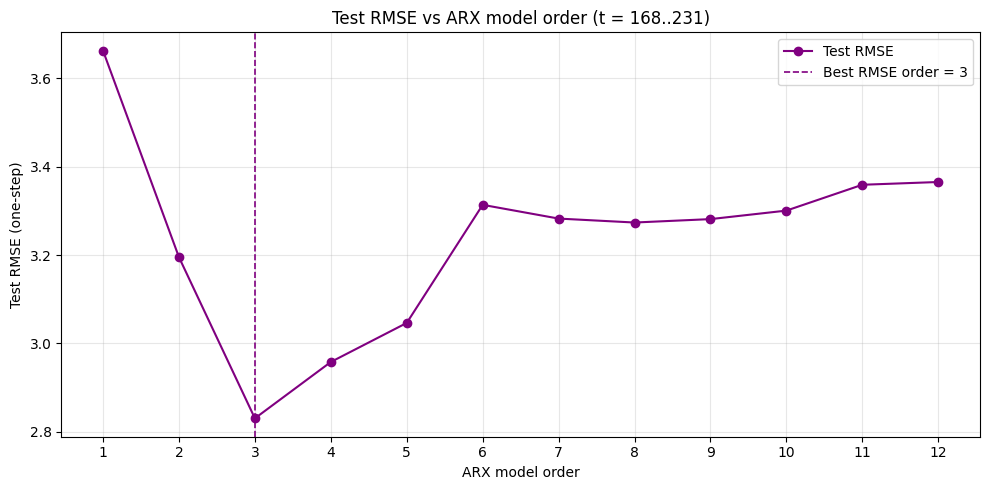

 order  RMSE_test  n_eval
     1   3.662864      64
     2   3.195292      64
     3   2.830383      64
     4   2.958011      64
     5   3.046431      64
     6   3.313856      64
     7   3.282741      64
     8   3.273807      64
     9   3.281537      64
    10   3.300787      64
    11   3.359302      64
    12   3.365551      64

Best order by test RMSE: 3
Best order by AIC (3.7): 11
Best order by BIC (3.7): 6
Matches AIC? No
Matches BIC? No


In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

# Ensure full data exists
if 'df' not in globals():
    raise RuntimeError('Run the data-loading cells first so df is available.')

# Ensure train/test split exists (same as earlier: first 167 train, remaining 64 test)
if 'train_df' not in globals() or 'test_df' not in globals():
    train_size = 167
    train_df = df.iloc[:train_size].copy()
    test_df = df.iloc[train_size:].copy()

def build_arx_design(data, order):
    work = data.copy()

    # Output lags: 1..order
    for lag in range(1, order + 1):
        src = f'Ph.l{lag}'
        col = f'Ph_l{lag}'
        if src in work.columns:
            work[col] = work[src]
        else:
            work[col] = work['Ph'].shift(lag)

    # Input lags: 0..order-1 (same number of lags for all inputs)
    for lag in range(0, order):
        src_td = f'Tdelta.l{lag}'
        src_gv = f'Gv.l{lag}'
        col_td = f'Tdelta_l{lag}'
        col_gv = f'Gv_l{lag}'
        if lag == 0:
            work[col_td] = work['Tdelta']
            work[col_gv] = work['Gv']
        else:
            work[col_td] = work[src_td] if src_td in work.columns else work['Tdelta'].shift(lag)
            work[col_gv] = work[src_gv] if src_gv in work.columns else work['Gv'].shift(lag)

    feature_cols = [f'Ph_l{lag}' for lag in range(1, order + 1)] + [
        f'Tdelta_l{lag}' for lag in range(0, order)
    ] + [
        f'Gv_l{lag}' for lag in range(0, order)
    ]

    design = work[['Ph'] + feature_cols].copy()
    return design, feature_cols

max_order = 12
train_size = 167
test_start_idx = train_size          # 0-based index for t=168
test_end_idx = train_size + 64 - 1   # 0-based index for t=231

rmse_records = []

for p in range(1, max_order + 1):
    # Fit on training sample only
    train_design, feature_cols = build_arx_design(train_df, p)
    train_fit = train_design.dropna()
    y_train = train_fit['Ph']
    X_train = sm.add_constant(train_fit[feature_cols])
    model_p = sm.OLS(y_train, X_train).fit()

    # One-step prediction through test period (uses observed lagged values)
    full_design, _ = build_arx_design(df, p)
    test_design = full_design.loc[test_start_idx:test_end_idx, ['Ph'] + feature_cols].dropna().copy()

    # Keep exactly the requested test window when possible
    if len(test_design) != 64:
        # If high order removes early rows, align to available rows and report n
        n_eval = len(test_design)
    else:
        n_eval = 64

    y_test = test_design['Ph']
    X_test = sm.add_constant(test_design[feature_cols], has_constant='add')
    y_hat = model_p.predict(X_test)
    residuals = y_test - y_hat
    rmse = np.sqrt(np.mean(residuals**2))

    rmse_records.append({
        'order': p,
        'RMSE_test': rmse,
        'n_eval': int(n_eval)
    })

rmse_df = pd.DataFrame(rmse_records)
best_rmse_order = int(rmse_df.loc[rmse_df['RMSE_test'].idxmin(), 'order'])

plt.figure(figsize=(10, 5))
plt.plot(rmse_df['order'], rmse_df['RMSE_test'], marker='o', color='purple', label='Test RMSE')
plt.axvline(best_rmse_order, linestyle='--', linewidth=1.2, color='purple', label=f'Best RMSE order = {best_rmse_order}')
plt.xlabel('ARX model order')
plt.ylabel('Test RMSE (one-step)')
plt.title('Test RMSE vs ARX model order (t = 168..231)')
plt.xticks(rmse_df['order'])
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print(rmse_df.to_string(index=False))
print(f'\nBest order by test RMSE: {best_rmse_order}')

if 'arx_order_results' in globals():
    aic_order = arx_order_results['best_aic_order']
    bic_order = arx_order_results['best_bic_order']
    print(f'Best order by AIC (3.7): {aic_order}')
    print(f'Best order by BIC (3.7): {bic_order}')
    print('Matches AIC?', 'Yes' if best_rmse_order == aic_order else 'No')
    print('Matches BIC?', 'Yes' if best_rmse_order == bic_order else 'No')

arx_test_results = {
    'rmse_table': rmse_df,
    'best_rmse_order': best_rmse_order
}

### Comment on test RMSE vs order (fill with your values)

- The minimum test RMSE is obtained at order **p = ...**.
- AIC selected **p = ...** and BIC selected **p = ...**.
- Therefore, the test-RMSE-optimal order **does / does not** coincide with AIC and **does / does not** coincide with BIC.

Interpretation:

- AIC/BIC are in-sample information criteria with complexity penalties (BIC penalizes complexity more strongly).
- Test RMSE is out-of-sample prediction accuracy.
- If they differ, it is common to prioritize test RMSE for forecasting performance and BIC for model parsimony/explainability.

### 3.9. Multi-step prediction (simulation) over the full period

Use the selected ARX order, fit on training data only, and simulate from the beginning of training to the end of test by:

- using observed inputs ($T_{\delta}$ and $G_v$),
- updating AR lags iteratively from simulated $\hat P_h$ values (not observed $P_h$),
- then evaluating performance on the test period.

<>:102: SyntaxWarning: "\h" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\h"? A raw string is also an option.
<>:102: SyntaxWarning: "\h" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\h"? A raw string is also an option.
C:\Users\leahi\AppData\Local\Temp\ipykernel_30252\642199765.py:102: SyntaxWarning: "\h" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\h"? A raw string is also an option.
  plt.plot(sim_df.index, sim_df['Ph_sim'], '--', label=f'Simulated $\hat P_h$ (ARX order {p_sel})', linewidth=1.6)


Selected order for simulation: p = 3 (best test-RMSE order from 3.8)
Test RMSE (simulation, t=168..231): 3.3536
Computed over N = 64 points


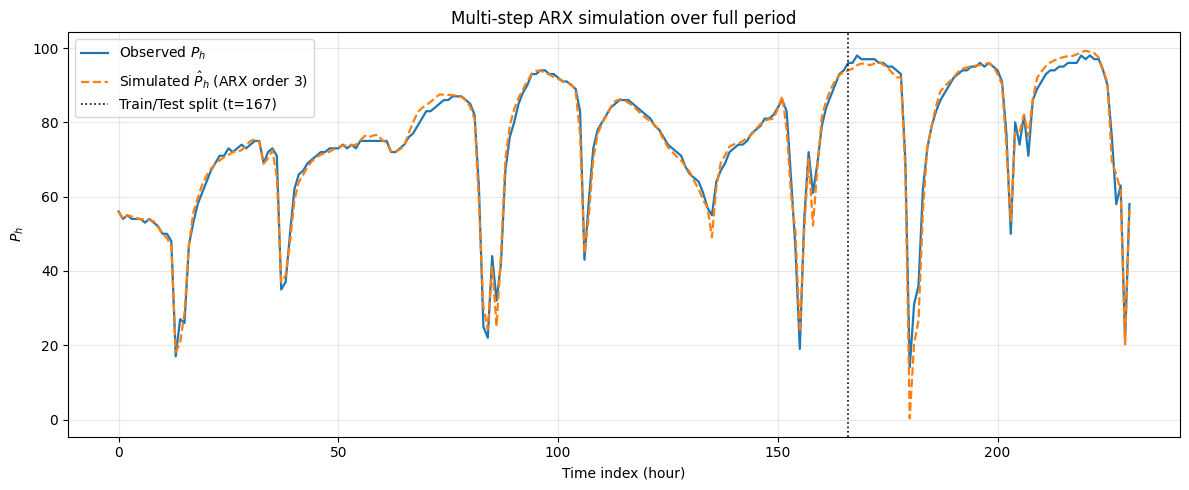

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

# Select model order (priority: test RMSE from 3.8, else BIC from 3.7, else 1)
if 'arx_test_results' in globals() and 'best_rmse_order' in arx_test_results:
    p_sel = int(arx_test_results['best_rmse_order'])
    p_source = 'best test-RMSE order from 3.8'
elif 'arx_order_results' in globals() and 'best_bic_order' in arx_order_results:
    p_sel = int(arx_order_results['best_bic_order'])
    p_source = 'best BIC order from 3.7'
else:
    p_sel = 1
    p_source = 'fallback order = 1'

print(f'Selected order for simulation: p = {p_sel} ({p_source})')

# Helper to build design (same lag convention as 3.7/3.8)
def build_arx_design_sim(data, order):
    work = data.copy()

    # Output lags: 1..order
    for lag in range(1, order + 1):
        src = f'Ph.l{lag}'
        col = f'Ph_l{lag}'
        if src in work.columns:
            work[col] = work[src]
        else:
            work[col] = work['Ph'].shift(lag)

    # Input lags: 0..order-1
    for lag in range(0, order):
        src_td = f'Tdelta.l{lag}'
        src_gv = f'Gv.l{lag}'
        col_td = f'Tdelta_l{lag}'
        col_gv = f'Gv_l{lag}'
        if lag == 0:
            work[col_td] = work['Tdelta']
            work[col_gv] = work['Gv']
        else:
            work[col_td] = work[src_td] if src_td in work.columns else work['Tdelta'].shift(lag)
            work[col_gv] = work[src_gv] if src_gv in work.columns else work['Gv'].shift(lag)

    feature_cols = [f'Ph_l{lag}' for lag in range(1, order + 1)] + [
        f'Tdelta_l{lag}' for lag in range(0, order)
    ] + [
        f'Gv_l{lag}' for lag in range(0, order)
    ]

    return work, feature_cols

# Fit selected ARX model on training data only
if 'train_df' not in globals():
    train_size = 167
    train_df = df.iloc[:train_size].copy()
else:
    train_size = len(train_df)

train_work, feature_cols_sel = build_arx_design_sim(train_df, p_sel)
train_fit = train_work[['Ph'] + feature_cols_sel].dropna().copy()
y_train = train_fit['Ph']
X_train = sm.add_constant(train_fit[feature_cols_sel], has_constant='add')
model_sel = sm.OLS(y_train, X_train).fit()

# Multi-step simulation over full period using observed inputs + iterative AR lags
n_total = len(df)
ph_sim = np.full(n_total, np.nan)

# Warm start first p values with observed Ph
ph_sim[:p_sel] = df['Ph'].iloc[:p_sel].values

for t in range(p_sel, n_total):
    row = {}
    for lag in range(1, p_sel + 1):
        row[f'Ph_l{lag}'] = ph_sim[t - lag]
    for lag in range(0, p_sel):
        row[f'Tdelta_l{lag}'] = df['Tdelta'].iloc[t - lag]
        row[f'Gv_l{lag}'] = df['Gv'].iloc[t - lag]

    x_row = pd.DataFrame([row])
    x_row = sm.add_constant(x_row, has_constant='add')
    x_row = x_row.reindex(columns=X_train.columns, fill_value=0.0)
    ph_sim[t] = model_sel.predict(x_row).iloc[0]

sim_df = df.copy()
sim_df['Ph_sim'] = ph_sim
sim_df['sim_resid'] = sim_df['Ph'] - sim_df['Ph_sim']

# RMSE on requested test period t=168..231 (0-based indices 167..230)
test_start = 167
test_end = 230
res_test = sim_df.loc[test_start:test_end, 'sim_resid']
rmse_sim_test = float(np.sqrt(np.mean(res_test**2)))

print(f'Test RMSE (simulation, t=168..231): {rmse_sim_test:.4f}')
print(f'Computed over N = {res_test.shape[0]} points')

# Plot full-period simulation
plt.figure(figsize=(12, 5))
plt.plot(sim_df.index, sim_df['Ph'], label='Observed $P_h$', linewidth=1.6)
plt.plot(sim_df.index, sim_df['Ph_sim'], '--', label=f'Simulated $\hat P_h$ (ARX order {p_sel})', linewidth=1.6)
plt.axvline(train_size - 1, color='black', linestyle=':', linewidth=1.2, label='Train/Test split (t=167)')
plt.title('Multi-step ARX simulation over full period')
plt.xlabel('Time index (hour)')
plt.ylabel('$P_h$')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

sim_results = {
    'order_selected': p_sel,
    'order_source': p_source,
    'model': model_sel,
    'sim_df': sim_df,
    'rmse_test_sim': rmse_sim_test
}

### Comment on multi-step simulation (fill with your values)

- Selected model order: **p = ...** (chosen from ...).
- Test-period simulation RMSE (t = 168..231): **...**.
- The simulated trajectory follows / does not fully follow the observed dynamics in the test period.

Interpretation hint:

- In simulation mode, AR terms are fed by previous predictions, so errors can accumulate over time.
- Therefore simulation RMSE is often larger than one-step-ahead RMSE.
- If the model still tracks the main dynamics, the selected order is reasonable for long-horizon simulation.

### Interpretation : 

For real-time operation:


In 3.9, the model can follow the overall heating dynamics, but multi-step simulation errors tend to accumulate because each new AR term uses previous predictions rather than true (P_h).
So compared with one-step-ahead forecasts, multi-step predictions are usually less accurate, especially farther into the horizon.
If your 3.9 plot shows trend/level tracking with moderate deviation, then the model is useful but not perfect for multi-step prediction.
Yes, feasible in principle: at each new hour you observe (T_{\delta}) and (G_v), update the model state, and roll predictions forward.
Best practice is to run it in a receding-horizon way (frequent re-initialization with newest measurements), not as a long open-loop simulation.
So: operationally possible, but reliability depends on periodic recalibration, input quality, and keeping forecast horizon moderate.

### TODO LEA : 

- Run the whole interval prediction on different model orders to check whether ARX 3 is indeed the best choice here!!
